In [5]:
# --- IMPORTS ---
import pandas as pd              # Práca s tabuľkami (DataFrame)
import numpy as np               # Matematika a polia
import matplotlib.pyplot as plt  # Základné grafy
import seaborn as sns            # Krajšie štatistické grafy
import scipy.stats as stats      # Štatistické testy (T-testy, ANOVA...)
import statsmodels.api as sm     # Pokročilá štatistika (Regresia)
import statsmodels.formula.api as smf # R-style formuly pre regresiu

# Nastavenie dizajnu grafov
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

print("✅ Libraries successfully loaded!")

✅ Libraries successfully loaded!


In [33]:
try:
    df = pd.read_csv("dataset/pollution_data.csv", sep=";")
    print("✅ Data successfully loaded.")
except FileNotFoundError:
    print("ERROR: File not found.")

df.head()

✅ Data successfully loaded.


,Date,City,County,State,Population Staying at Home,Population Not Staying at Home,mil_miles,past_week_avg_miles,latitude,longitude,...,pm10_max,pm10_median,pm10_variance,pm10_count,wind-gust_min,wind-gust_max,wind-gust_median,wind-gust_variance,wind-gust_count,pp_feat
0,01.01.2019,albuquerque,bernalillo,NM,"1,77,171","4,99,456",19.038463,0,35.107209,-106.617209,...,127.0,18.0,5303.29,48.0,0.3,27.3,3.8,839.84,54.0,0.319492
1,01.01.2019,atlanta,fulton,GA,"2,83,093","7,63,811",29.295609,0,33.760109,-84.402826,...,27.0,14.0,280.83,23.0,0.1,4.5,1.7,12.11,44.0,23.304216
2,01.01.2019,austin,travis,TX,"2,68,732","9,76,194",27.286079,0,30.283333,-97.750641,...,NaN,NaN,NaN,NaN,0.2,14.0,6.8,162.34,67.0,14.333042
3,01.01.2019,baltimore,baltimo,MD,"1,91,486","4,09,167",12.961132,0,39.305833,-76.610417,...,15.0,6.0,74.76,24.0,0.1,24.0,8.5,355.46,70.0,6.403240
4,01.01.2019,boise,ada,ID,"1,05,237","3,63,293",12.640954,0,43.604545,-116.202424,...,20.0,5.0,170.86,47.0,0.1,11.3,2.2,46.19,92.0,0.000000


In [10]:
df.columns

Index(['Date', 'City', 'County', 'State', 'Population Staying at Home',
       'Population Not Staying at Home', 'mil_miles', 'past_week_avg_miles',
       'latitude', 'longitude', 'o3_min', 'o3_max', 'o3_median', 'o3_variance',
       'o3_count', 'pressure_min', 'pressure_max', 'pressure_median',
       'pressure_variance', 'pressure_count', 'pm25_min', 'pm25_max',
       'pm25_median', 'pm25_variance', 'pm25_count', 'humidity_min',
       'humidity_max', 'humidity_median', 'humidity_variance',
       'humidity_count', 'temperature_min', 'temperature_max',
       'temperature_median', 'temperature_variance', 'temperature_count',
       'dew_min', 'dew_max', 'dew_median', 'dew_variance', 'dew_count',
       'no2_min', 'no2_max', 'no2_median', 'no2_variance', 'no2_count',
       'wind-speed_min', 'wind-speed_max', 'wind-speed_median',
       'wind-speed_variance', 'wind-speed_count', 'co_min', 'co_max',
       'co_median', 'co_variance', 'co_count', 'so2_min', 'so2_max',
       'so2_med

Vysvetli **x=o3_median** pomocou regresorov Population, latitude, longitude, mil_miles, 'Population Staying at Home', State, 'Population Not Staying at Home'
* V exceli musia byt stlpci regresorov vedla seba

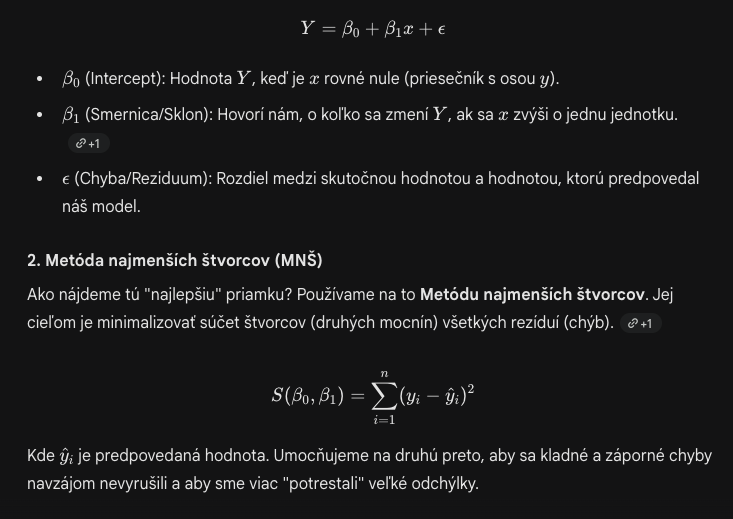
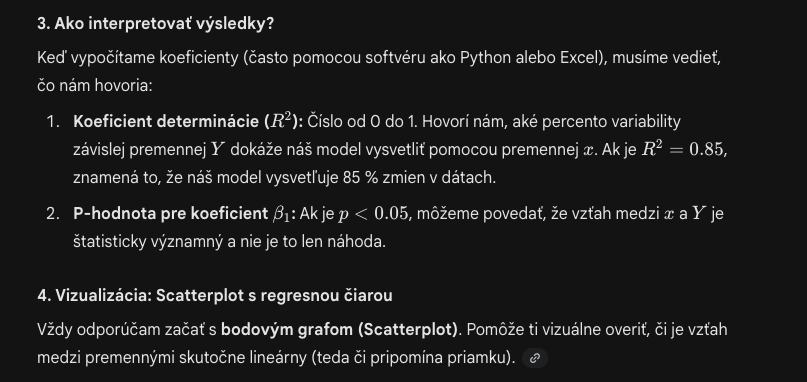


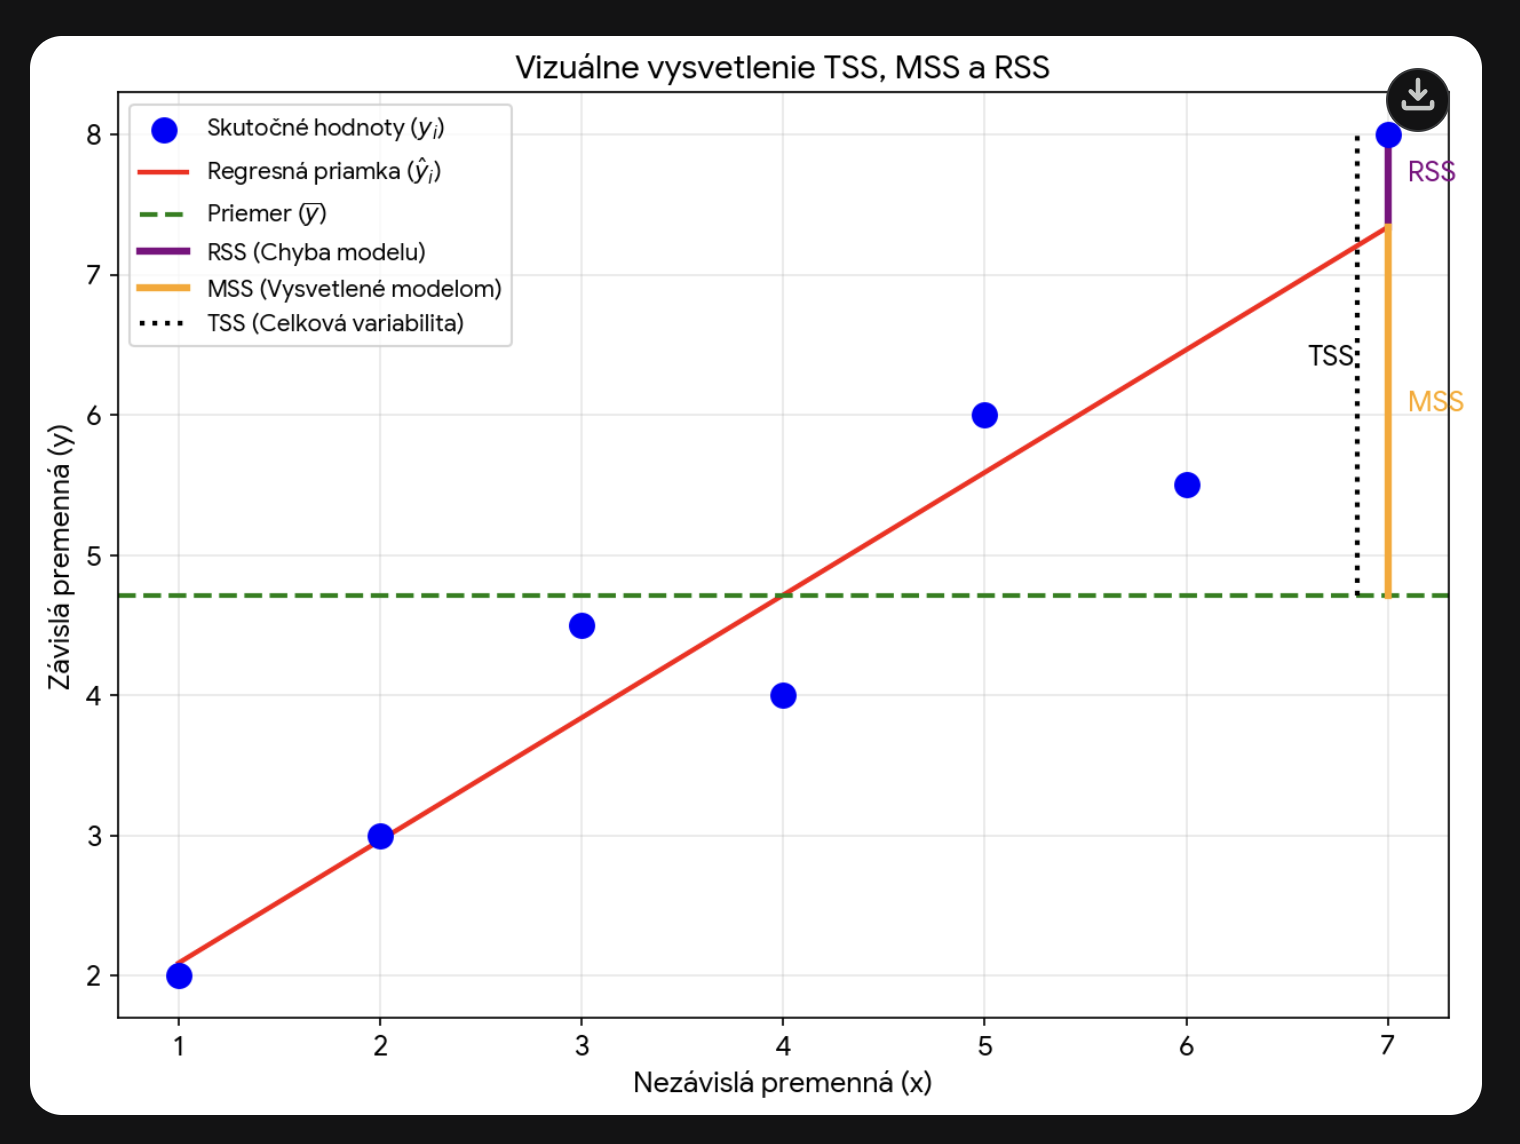
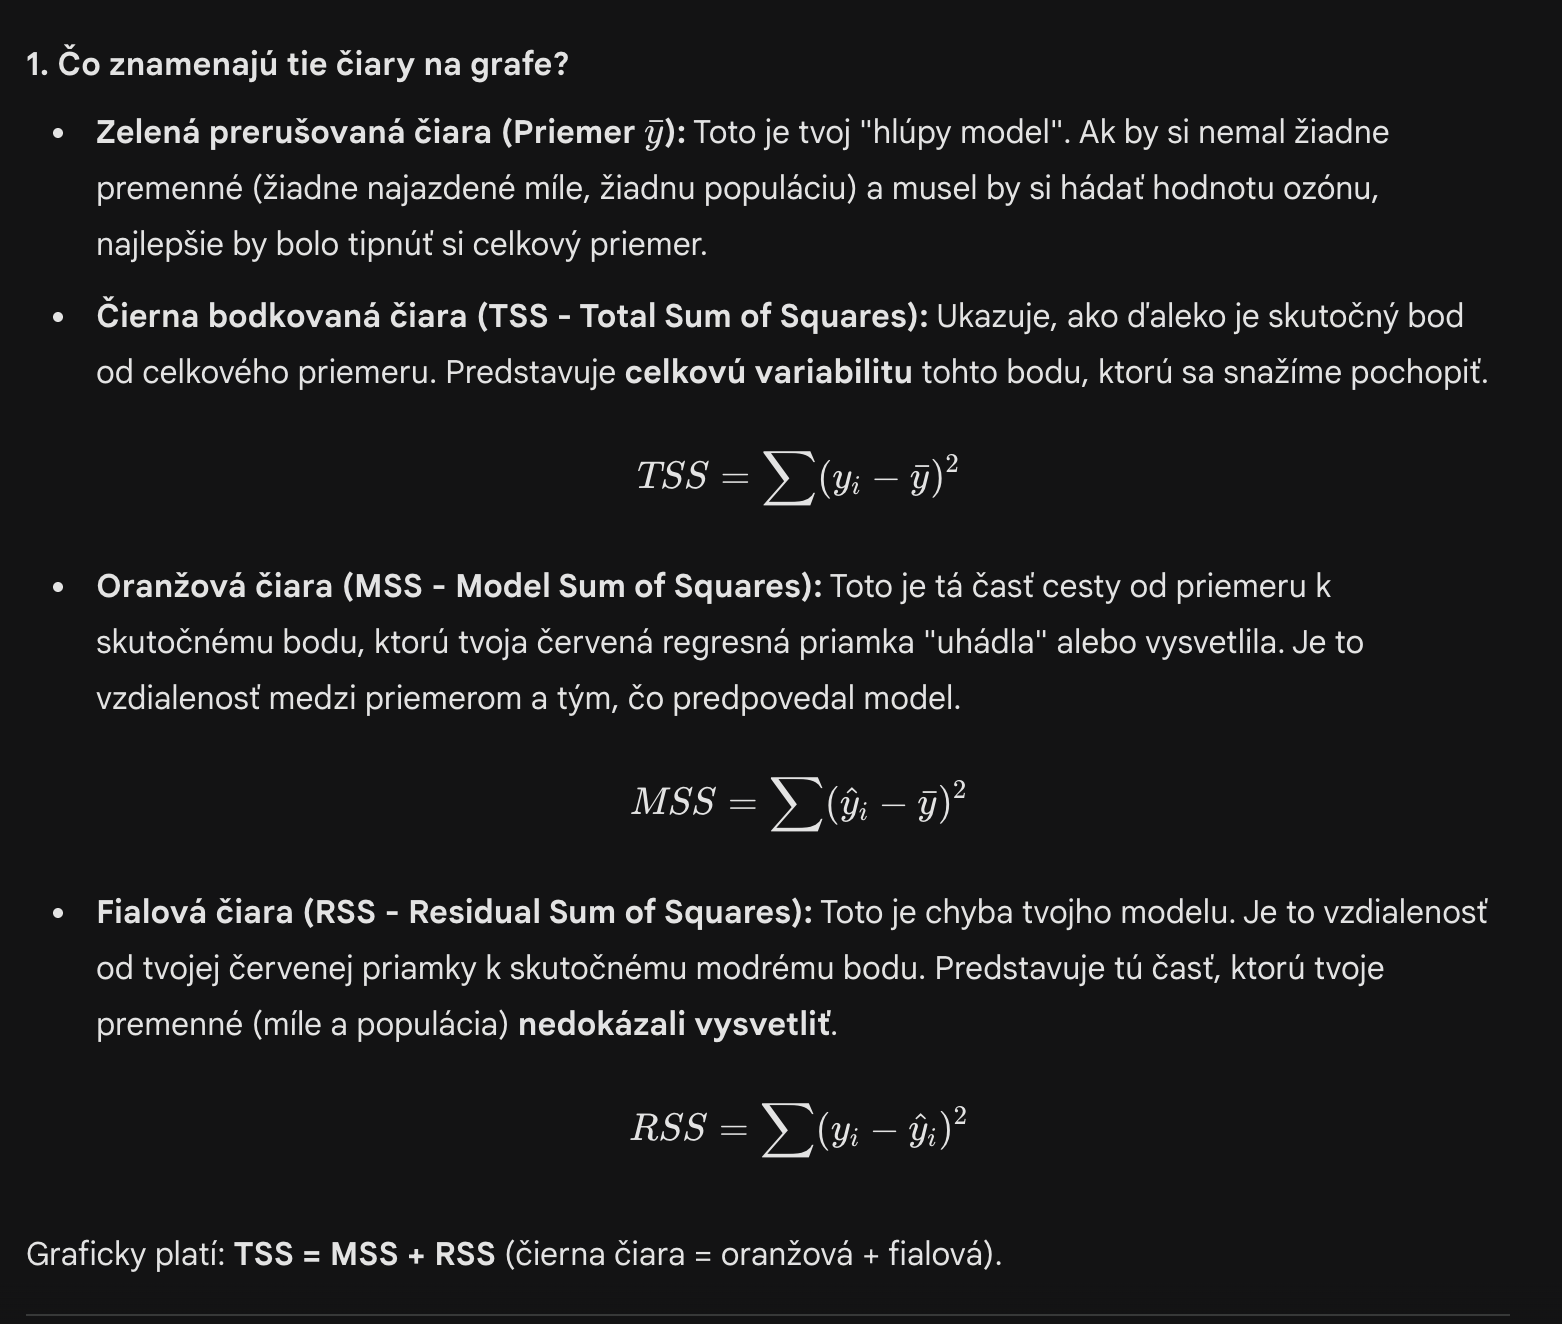

In [28]:
# 2. Vyčistenie názvov stĺpcov
df.columns = df.columns.str.strip()

# 3. Funkcia na bezpečný prevod na číslo
def clean_number(value):
    if pd.isna(value): return None
    # Ak je to string a obsahuje čiarku, odstránime ju
    val_str = str(value).replace(',', '')
    return pd.to_numeric(val_str, errors='coerce')

# Aplikujeme na tvoje premenné
cols = ['Population Staying at Home', 'Population Not Staying at Home', 'mil_miles']
target = 'o3_median'

for col in cols + [target]:
    df[col] = df[col].apply(clean_number)

# 4. Diagnostika - koľko dát máme v ktorom stĺpci?
print("Počet platných čísiel v jednotlivých stĺpcoch:")
print(df[cols + [target]].count())

# 5. Odstránenie NaN a spustenie regresie
df_clean = df.dropna(subset=cols + [target])
print(f"\nFinálny počet riadkov pre model: {len(df_clean)}")

if len(df_clean) > 0:
    X = df_clean[cols]
    y = df_clean[target]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()  # Ordinary least square = fith the best linear line
    print(model.summary())
else:
    print("⚠️ Model stále nemá dáta. Skúsme namiesto 'o3_median' použiť 'temperature_median'.")

Počet platných čísiel v jednotlivých stĺpcoch:
Population Staying at Home        35596
Population Not Staying at Home    35596
mil_miles                         35596
o3_median                         33950
dtype: int64

Finálny počet riadkov pre model: 33950
                            OLS Regression Results                            
Dep. Variable:              o3_median   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     180.9
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          2.18e-116
Time:                        09:50:41   Log-Likelihood:            -1.6119e+05
No. Observations:               33950   AIC:                         3.224e+05
Df Residuals:                   33946   BIC:                         3.224e+05
Df Model:                           3                                         
Covariance Type:            n

## Notes:
Vzorec: $$t = coef/ stderr$$  pri jednotlivych regresoroch (napr. Population Staying at Home) tak dostanem hodnoty  **t-stat**
* ak ich hodnotu si v abs. hodnote vacsie ako cca 2 (**p<0.05**), tak parametre posobia na nas **y** (o3)
* **Zaporna hodnota** Population Not Staying at Home -1.589e-05 -> klesajuca zavislost - cim viac ludi ide prec z domu tym je mensia o3 (asi vycestuju?)
* **Kladna hodnota** mil_miles - 0.2055 -> kladna linearna zaivslost - cim viac jazdim, tym viac prispevam k o3
* **Rˆ2 je nizka**, previazanost modelu je velmi slaba na predikciu ozonu

In [29]:
# MSS v Exceli je vlastne TSS - RSS

# MSS (Model Sum of Squares) sa v statsmodels volá 'ess' (Explained Sum of Squares)
mss = model.ess

# RSS (Residual Sum of Squares) sa volá 'ssr' (Sum of Squared Residuals)
rss = model.ssr

# TSS (Total Sum of Squares) sa volá 'centered_tss' 
tss = model.centered_tss

print(f"MSS (Vysvetlené modelom): {mss}")
print(f"RSS (Chyba modelu): {rss}")
print(f"TSS (Celková variabilita): {tss}")

# Rýchla kontrola, či matematika sedí:
print(f"Súčet MSS + RSS = {mss + rss} (Malo by sa rovnať TSS: {tss})")

#######

total_ss = ((y - y.mean())**2).sum()  # TSS
residual_ss = model.ssr               # RSS v statsmodels
model_ss = total_ss - residual_ss      # MSS (Regrese v Exceli) Python: ESS (Explained Sum of Squares)

# r2 = mss/tss
r2 = model_ss / total_ss

print(f"Excelovské MSS (Regrese): {model_ss}")
print(f"Rˆ2 (Regrese): {r2}")

MSS (Vysvetlené modelom): 422707.1124906689
RSS (Chyba modelu): 26437090.593890477
TSS (Celková variabilita): 26859797.706381146
Súčet MSS + RSS = 26859797.706381146 (Malo by sa rovnať TSS: 26859797.706381146)
Excelovské MSS (Regrese): 422707.1124906689
Rˆ2 (Regrese): 0.01573753894617923


# ANOVA
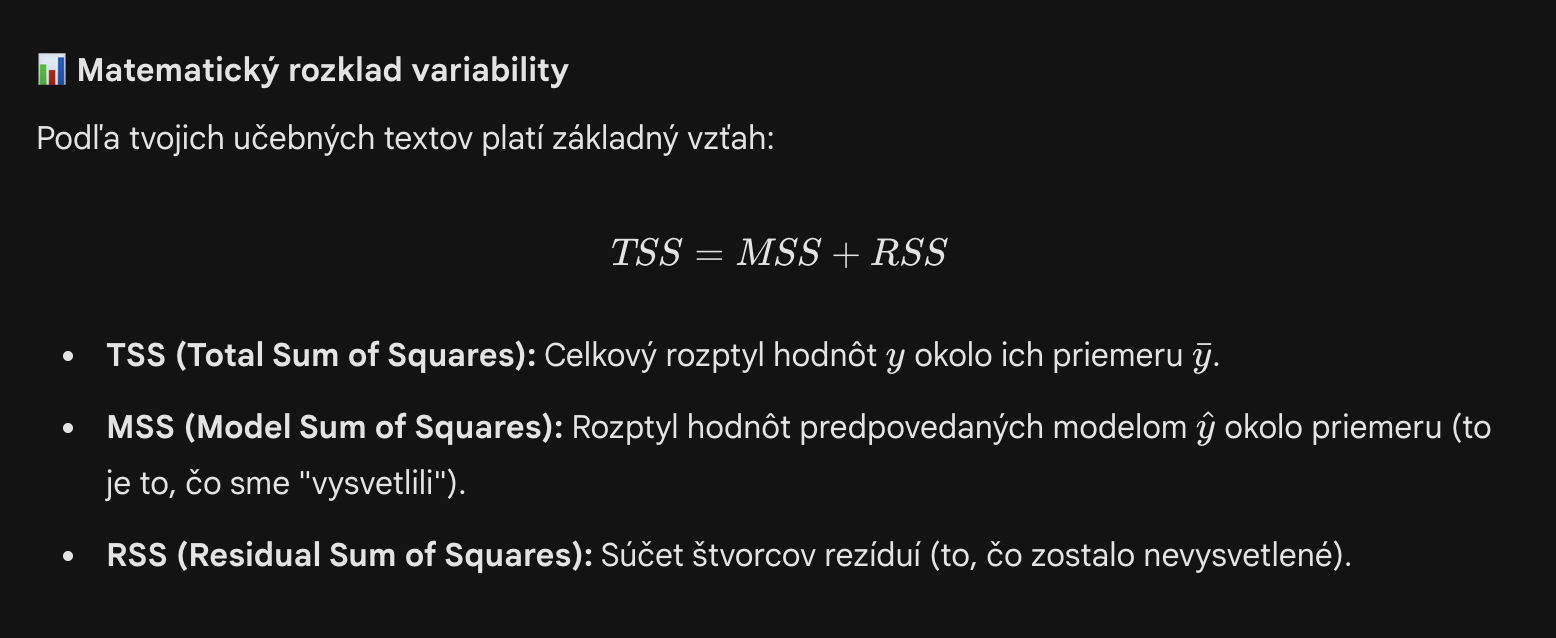

In [27]:
from statsmodels.formula.api import ols

formula = 'o3_median ~ Q("Population Staying at Home") + Q("Population Not Staying at Home") + mil_miles'
model_anova = ols(formula, data=df_clean).fit()

# 2. Vygenerovanie ANOVA tabuľky
anova_table = sm.stats.anova_lm(model_anova, typ=2)

# 3. Výpočet TSS, MSS (v tabuľke ako sum_sq pre model) a RSS (sum_sq pre Residual)
mss = anova_table['sum_sq'].iloc[:-1].sum() # Súčet sum_sq pre všetky regresory
rss = anova_table['sum_sq'].iloc[-1]        # sum_sq pre Residual
tss = mss + rss

print("--- ANALÝZA ROZPTYLU (ANOVA) ---")
print(f"MSS (Model Sum of Squares): {mss:.2f}")
print(f"RSS (Residual Sum of Squares): {rss:.2f}")
print(f"TSS (Total Sum of Squares): {tss:.2f}")
print("\nPodrobná ANOVA tabuľka:")
print(anova_table)

--- ANALÝZA ROZPTYLU (ANOVA) ---
MSS (Model Sum of Squares): 830472.87
RSS (Residual Sum of Squares): 26437090.59
TSS (Total Sum of Squares): 27267563.46

Podrobná ANOVA tabuľka:
                                           sum_sq       df           F  \
Q("Population Staying at Home")      4.165896e+05      1.0  534.913279   
Q("Population Not Staying at Home")  2.722504e+05      1.0  349.577507   
mil_miles                            1.416329e+05      1.0  181.860740   
Residual                             2.643709e+07  33946.0         NaN   

                                            PR(>F)  
Q("Population Staying at Home")      1.954831e-117  
Q("Population Not Staying at Home")   1.286956e-77  
mil_miles                             2.430636e-41  
Residual                                       NaN  


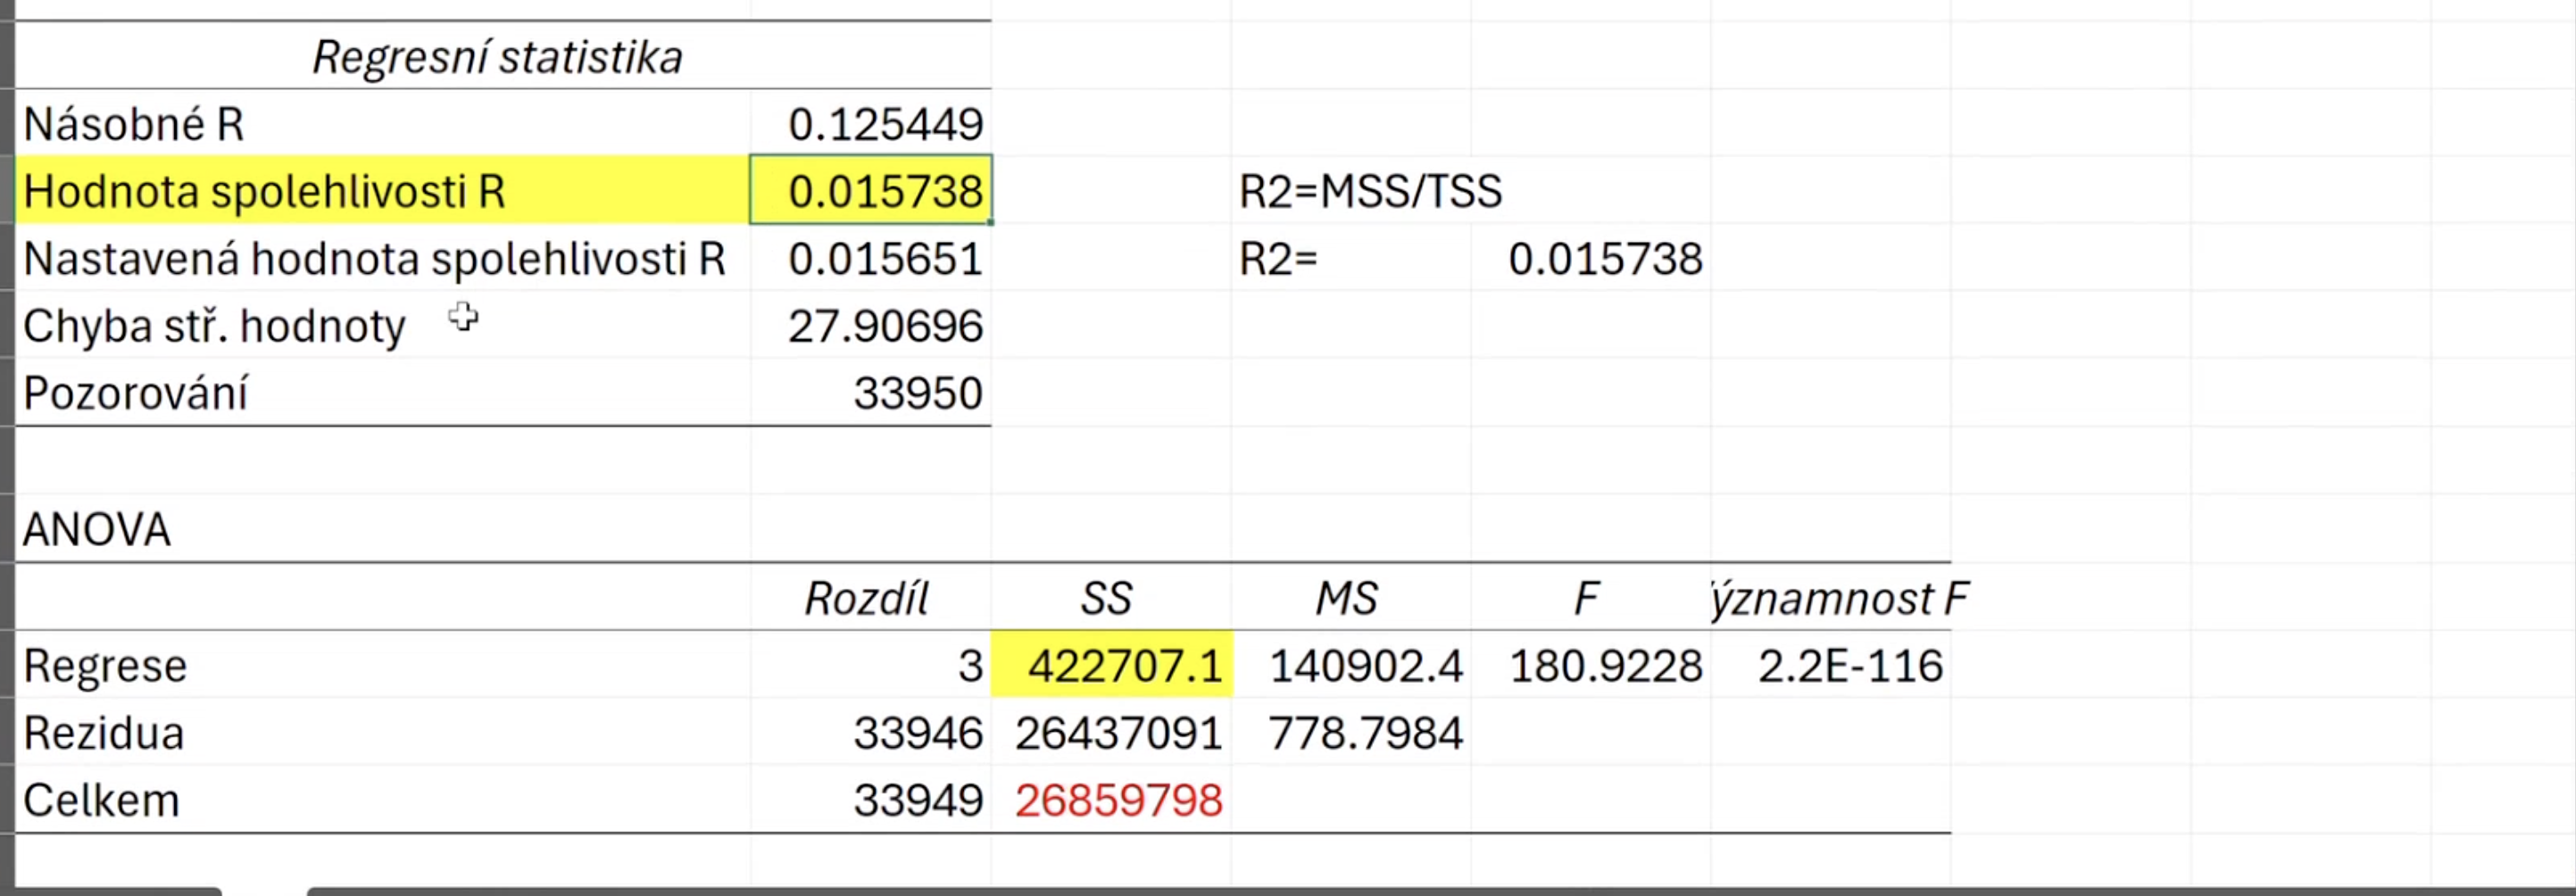